In [1]:
import pandas as pd #data processing
import numpy as np #linear algebra
import matplotlib.pyplot as plt #data visualisation
import seaborn as sns #data visualisation
%matplotlib inline
from sklearn.model_selection import train_test_split #data-validation
from sklearn.linear_model import LogisticRegression,LinearRegression #algortithm
from sklearn.metrics import accuracy_score,confusion_matrix,classification_report #evaluation
from sklearn.preprocessing import LabelEncoder,StandardScaler
from sklearn.decomposition import PCA


In [2]:
df=pd.read_csv("framingham.csv")
print("File read successfully")

File read successfully


In [3]:
df.head()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
0,1,39,4.0,0,0.0,0.0,0,0,0,195.0,106.0,70.0,26.97,80.0,77.0,0
1,0,46,2.0,0,0.0,0.0,0,0,0,250.0,121.0,81.0,28.73,95.0,76.0,0
2,1,48,1.0,1,20.0,0.0,0,0,0,245.0,127.5,80.0,25.34,75.0,70.0,0
3,0,61,3.0,1,30.0,0.0,0,1,0,225.0,150.0,95.0,28.58,65.0,103.0,1
4,0,46,3.0,1,23.0,0.0,0,0,0,285.0,130.0,84.0,23.10,85.0,85.0,0


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4238 entries, 0 to 4237
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   male             4238 non-null   int64  
 1   age              4238 non-null   int64  
 2   education        4133 non-null   float64
 3   currentSmoker    4238 non-null   int64  
 4   cigsPerDay       4209 non-null   float64
 5   BPMeds           4185 non-null   float64
 6   prevalentStroke  4238 non-null   int64  
 7   prevalentHyp     4238 non-null   int64  
 8   diabetes         4238 non-null   int64  
 9   totChol          4188 non-null   float64
 10  sysBP            4238 non-null   float64
 11  diaBP            4238 non-null   float64
 12  BMI              4219 non-null   float64
 13  heartRate        4237 non-null   float64
 14  glucose          3850 non-null   float64
 15  TenYearCHD       4238 non-null   int64  
dtypes: float64(9), int64(7)
memory usage: 529.9 KB


In [5]:
df.nunique()

male                  2
age                  39
education             4
currentSmoker         2
cigsPerDay           33
BPMeds                2
prevalentStroke       2
prevalentHyp          2
diabetes              2
totChol             248
sysBP               234
diaBP               146
BMI                1363
heartRate            73
glucose             143
TenYearCHD            2
dtype: int64

In [6]:
df.isnull().sum()

male                 0
age                  0
education          105
currentSmoker        0
cigsPerDay          29
BPMeds              53
prevalentStroke      0
prevalentHyp         0
diabetes             0
totChol             50
sysBP                0
diaBP                0
BMI                 19
heartRate            1
glucose            388
TenYearCHD           0
dtype: int64

In [7]:
df.shape

(4238, 16)

### Data Cleaning

In [8]:
#seprate column types
num_cols=df.select_dtypes(include=['int64','float64']).columns
cat_cols=df.select_dtypes(include=['object']).columns

In [9]:
#Fill numeric columns with median
df[num_cols]=df[num_cols].fillna(df[num_cols].median())

In [10]:
#Fill Categorical Columns with "unknown"
df[cat_cols] = df[cat_cols].fillna("Unknown")

In [11]:
df = df.drop_duplicates()

In [12]:
print("Missing values after cleaning:\n",df.isnull().sum())
print("shape after cleaning:",df.shape)

Missing values after cleaning:
 male               0
age                0
education          0
currentSmoker      0
cigsPerDay         0
BPMeds             0
prevalentStroke    0
prevalentHyp       0
diabetes           0
totChol            0
sysBP              0
diaBP              0
BMI                0
heartRate          0
glucose            0
TenYearCHD         0
dtype: int64
shape after cleaning: (4238, 16)


In [13]:
df.describe()

,male,age,education,currentSmoker,cigsPerDay,BPMeds,prevalentStroke,prevalentHyp,diabetes,totChol,sysBP,diaBP,BMI,heartRate,glucose,TenYearCHD
count,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000,4238.000000
mean,0.429212,49.584946,1.979471,0.494101,8.941482,0.029259,0.005899,0.310524,0.025720,236.689476,132.352407,82.893464,25.800205,75.878716,81.603587,0.151958
std,0.495022,8.572160,1.007081,0.500024,11.902399,0.168552,0.076587,0.462763,0.158316,44.327427,22.038097,11.910850,4.071041,12.025185,22.865246,0.359023
min,0.000000,32.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,107.000000,83.500000,48.000000,15.540000,44.000000,40.000000,0.000000
25%,0.000000,42.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,206.000000,117.000000,75.000000,23.080000,68.000000,72.000000,0.000000
50%,0.000000,49.000000,2.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,234.000000,128.000000,82.000000,25.400000,75.000000,78.000000,0.000000
75%,1.000000,56.000000,3.000000,1.000000,20.000000,0.000000,0.000000,1.000000,0.000000,262.000000,144.000000,89.875000,28.037500,83.000000,85.000000,0.000000
max,1.000000,70.000000,4.000000,1.000000,70.000000,1.000000,1.000000,1.000000,1.000000,696.000000,295.000000,142.500000,56.800000,143.000000,394.000000,1.000000


### Age Distribution

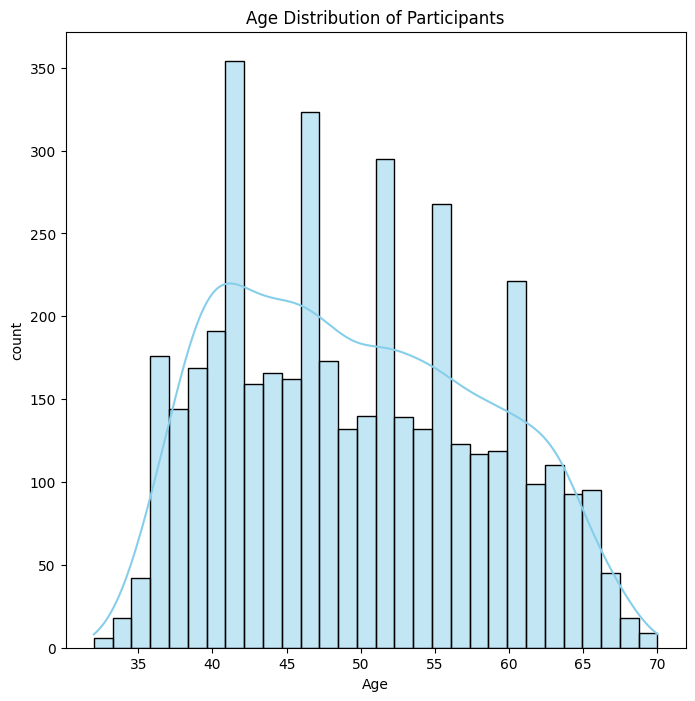

In [14]:
plt.figure(figsize=(8,8))
sns.histplot(data=df, x='age', bins=30, kde=True, color='skyblue')
plt.title("Age Distribution of Participants")
plt.xlabel("Age")
plt.ylabel("count")
plt.show()

Shows how participants’ ages are spread

Most are between 40–60 years

### Gender Distribution

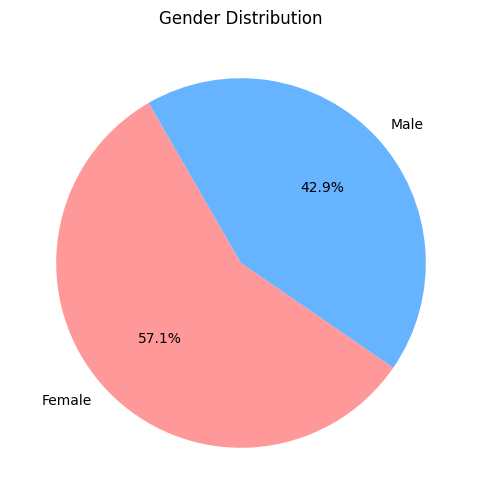

In [15]:
plt.figure(figsize=(6,6))
df['male'].value_counts().plot.pie(
    labels=['Female', 'Male'],  # 0=Female, 1=Male
    autopct='%1.1f%%',
    startangle=120,
    colors=['#ff9999','#66b3ff']
)
plt.title("Gender Distribution")
plt.ylabel("")
plt.show()

male=43%

female=57%

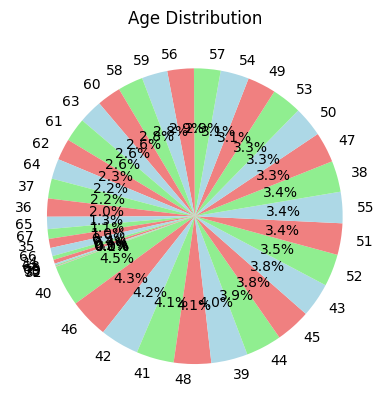

In [16]:
df['age'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=20000,
    colors=['lightgreen', 'lightcoral', 'lightblue'],
    labels=df['age'].value_counts().index
)
plt.title("Age Distribution")
plt.ylabel("")
plt.show()

In [17]:
# Value counts
values = df["TenYearCHD"].value_counts()

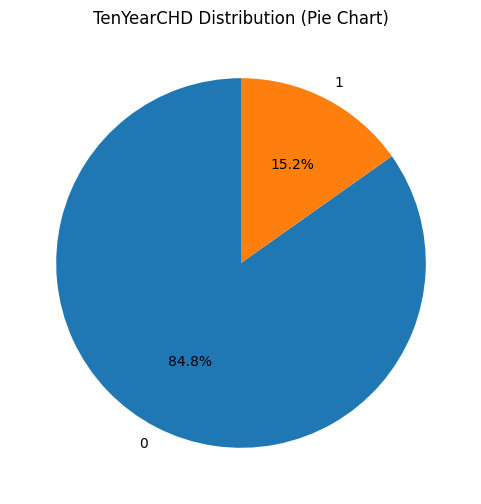

In [18]:
plt.figure(figsize=(6,6))
plt.pie(values, labels=values.index, autopct="%1.1f%%", startangle=90)
plt.title("TenYearCHD Distribution (Pie Chart)")
plt.show()

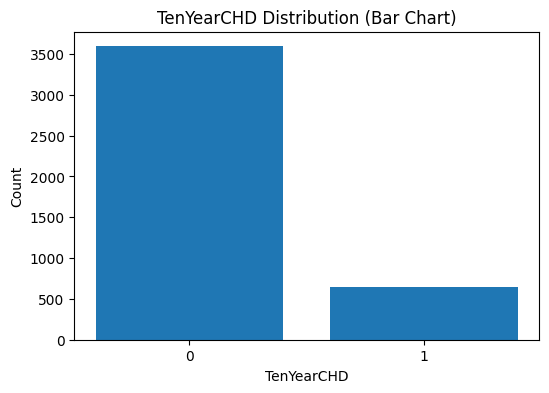

In [19]:
# Bar chart
plt.figure(figsize=(6,4))
plt.bar(values.index.astype(str), values.values)
plt.xlabel("TenYearCHD")
plt.ylabel("Count")
plt.title("TenYearCHD Distribution (Bar Chart)")
plt.show()

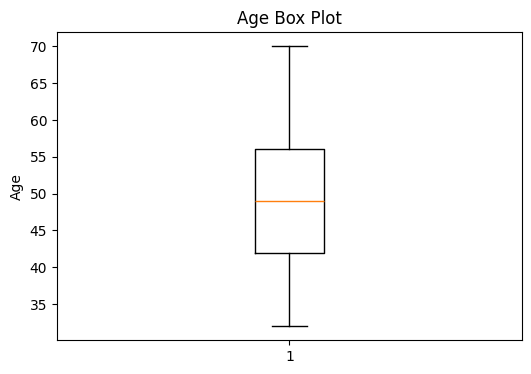

In [20]:
plt.figure(figsize=(6,4))
plt.boxplot(df["age"])
plt.title("Age Box Plot")
plt.ylabel("Age")
plt.show()


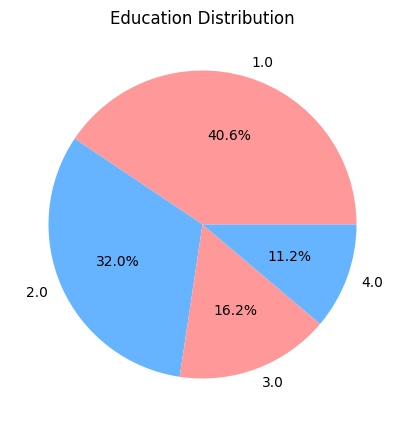

In [21]:
plt.figure(figsize=(6,5))
df['education'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Education Distribution')
plt.ylabel('')
plt.show()


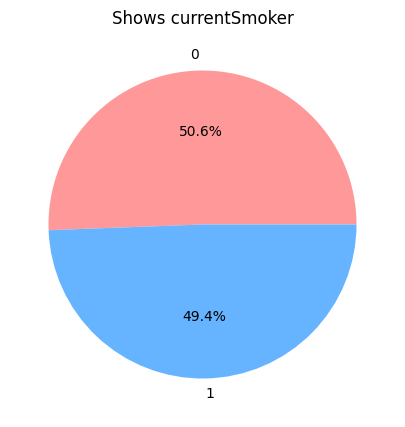

In [22]:
plt.figure(figsize=(6,5))
df['currentSmoker'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Shows currentSmoker')
plt.ylabel('')
plt.show()


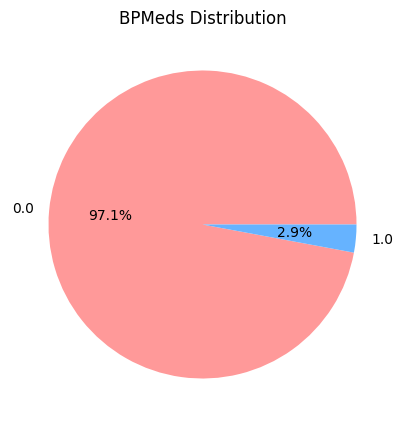

In [23]:
plt.figure(figsize=(6,5))
df['BPMeds'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('BPMeds Distribution')
plt.ylabel('')
plt.show()


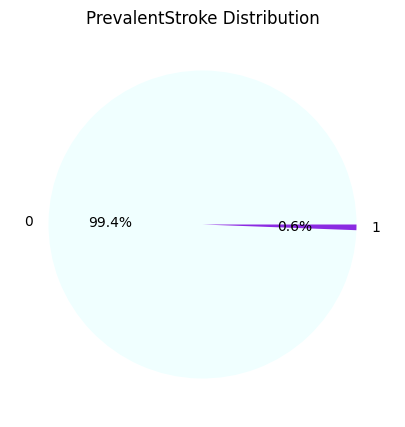

In [24]:
plt.figure(figsize=(6,5))
df['prevalentStroke'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#F0FFFF','#8A2BE2'])
plt.title('PrevalentStroke Distribution')
plt.ylabel('')
plt.show()


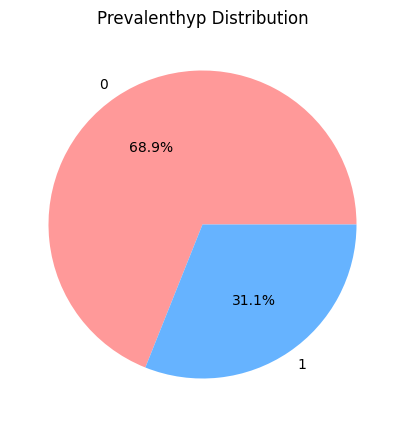

In [25]:
plt.figure(figsize=(6,5))
df['prevalentHyp'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Prevalenthyp Distribution')
plt.ylabel('')
plt.show()

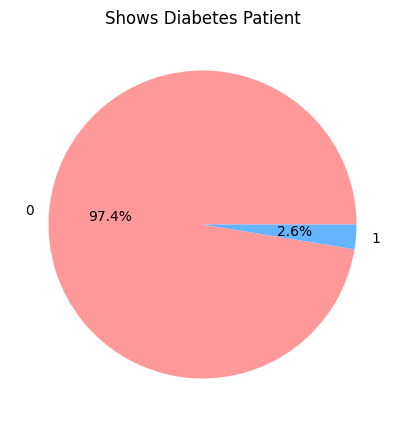

In [26]:
plt.figure(figsize=(6,5))
df['diabetes'].value_counts().plot(kind='pie', autopct='%1.1f%%', colors=['#ff9999','#66b3ff'])
plt.title('Shows Diabetes Patient')
plt.ylabel('')
plt.show()

### Correlation Heatmap

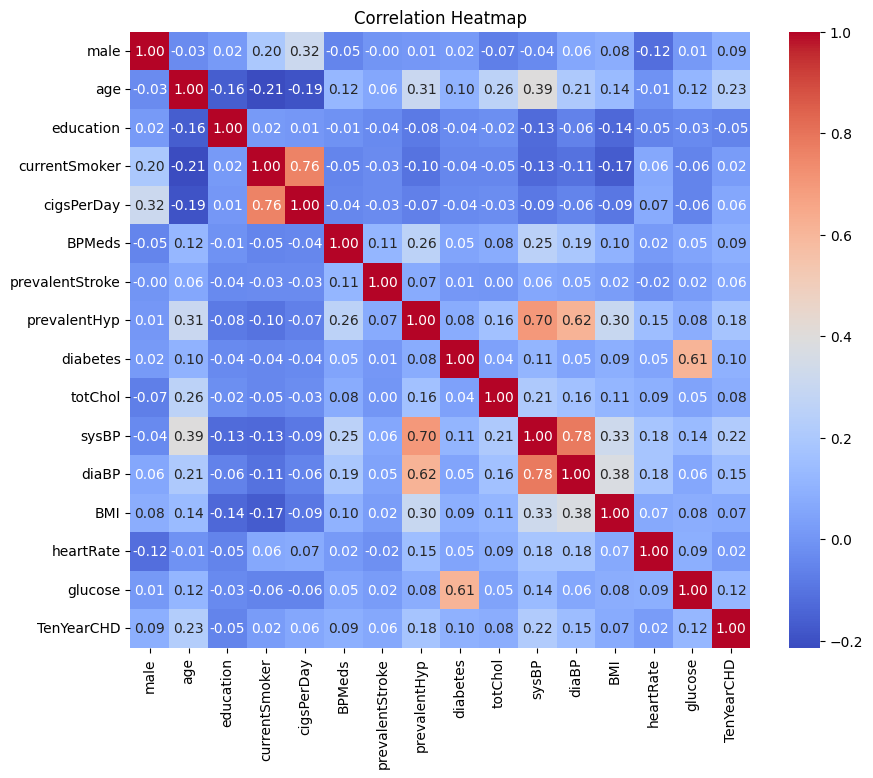

In [27]:
plt.figure(figsize=(10,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()

Shows relationships between numerical features
    
Example: sysBP and diaBP are strongly correlated

In [28]:
X=df[["age", "male", "education", "cigsPerDay", "totChol", "sysBP", "glucose"]]
y=df["TenYearCHD"]

In [29]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)
X_test = scaler.transform(df)

In [30]:
newdf=pd.DataFrame(X_scaled)
newdf.describe()

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14,15
count,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03,4.238000e+03
mean,-2.682559e-17,1.307747e-16,1.500556e-16,3.017879e-17,-4.945968e-17,-4.023838e-17,-1.005960e-17,-5.029798e-17,-4.359158e-17,-7.963846e-17,-4.510052e-16,2.984347e-16,5.314819e-16,-1.173619e-16,1.768812e-16,-1.739472e-17
std,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00,1.000118e+00
min,-8.671584e-01,-2.051644e+00,-9.726997e-01,-9.882708e-01,-7.513222e-01,-1.736116e-01,-7.703255e-02,-6.711009e-01,-1.624766e-01,-2.926062e+00,-2.216987e+00,-2.929899e+00,-2.520588e+00,-2.651309e+00,-1.819727e+00,-4.233055e-01
25%,-8.671584e-01,-8.849392e-01,-9.726997e-01,-9.882708e-01,-7.513222e-01,-1.736116e-01,-7.703255e-02,-6.711009e-01,-1.624766e-01,-6.924178e-01,-6.967125e-01,-6.627903e-01,-6.682630e-01,-6.552620e-01,-4.200576e-01,-4.233055e-01
50%,-8.671584e-01,-6.824590e-02,2.038662e-02,-9.882708e-01,-7.513222e-01,-1.736116e-01,-7.703255e-02,-6.711009e-01,-1.624766e-01,-6.068012e-02,-1.975180e-01,-7.502146e-02,-9.831699e-02,-7.308163e-02,-1.576196e-01,-4.233055e-01
75%,1.153192e+00,7.484475e-01,1.013473e+00,1.011868e+00,9.292096e-01,-1.736116e-01,-7.703255e-02,1.490089e+00,-1.624766e-01,5.710575e-01,5.285832e-01,5.862185e-01,5.496281e-01,5.922673e-01,1.485580e-01,-4.233055e-01
max,1.153192e+00,2.381834e+00,2.006559e+00,1.011868e+00,5.130539e+00,5.759984e+00,1.298153e+01,1.490089e+00,6.154733e+00,1.036299e+01,7.381163e+00,5.004980e+00,7.615608e+00,5.582384e+00,1.366411e+01,2.362360e+00


In [31]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [32]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
pred=model.predict(X_test)

In [33]:
y_pred = model.predict(X_test)

In [34]:
# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)
print("\nClassification Report:")
print(classification_report(y_test, y_pred))
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(cm)

Accuracy: 0.8561320754716981

Classification Report:
              precision    recall  f1-score   support

           0       0.86      0.99      0.92       724
           1       0.58      0.06      0.10       124

    accuracy                           0.86       848
   macro avg       0.72      0.52      0.51       848
weighted avg       0.82      0.86      0.80       848


Confusion Matrix:
[[719   5]
 [117   7]]


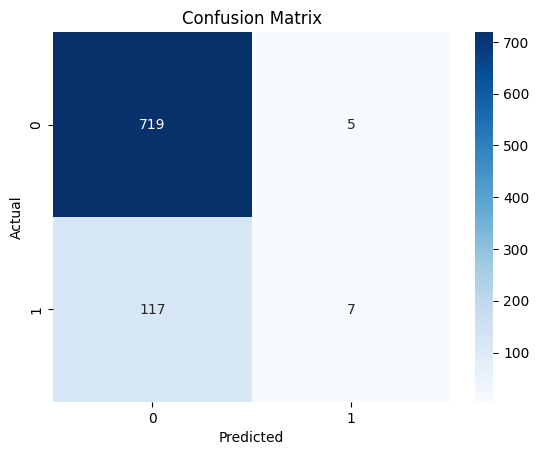

In [35]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
df_clean = df.dropna()

In [37]:
numeric_df = df_clean.select_dtypes(include=['float64','int64'])

In [38]:
X=df.drop("TenYearCHD", axis=1)
y=df["TenYearCHD"]

In [39]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df)

In [40]:
y_num = df_clean["TenYearCHD"].values

In [41]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

In [42]:
plt.figure(figsize=(12,5))

<Figure size 1200x500 with 0 Axes>

<Figure size 1200x500 with 0 Axes>

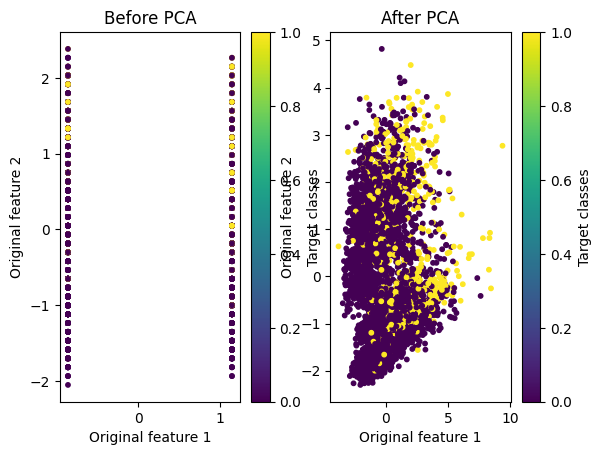

In [43]:
#Before PCA
plt.subplot(1,2,1)
plt.scatter(X_scaled[:,0],X_scaled[:,1],c=y_num,s=10)
plt.xlabel("Original feature 1")
plt.ylabel("Original feature 2")
plt.title("Before PCA")
plt.colorbar(label='Target classes')

#After PCA
plt.subplot(1,2,2)
plt.scatter(X_pca[:,0],X_pca[:,1],c=y_num,s=10)
plt.xlabel("Original feature 1")
plt.ylabel("Original feature 2")
plt.title("After PCA")
plt.colorbar(label='Target classes')
plt.show()

### Plotting Semester Result

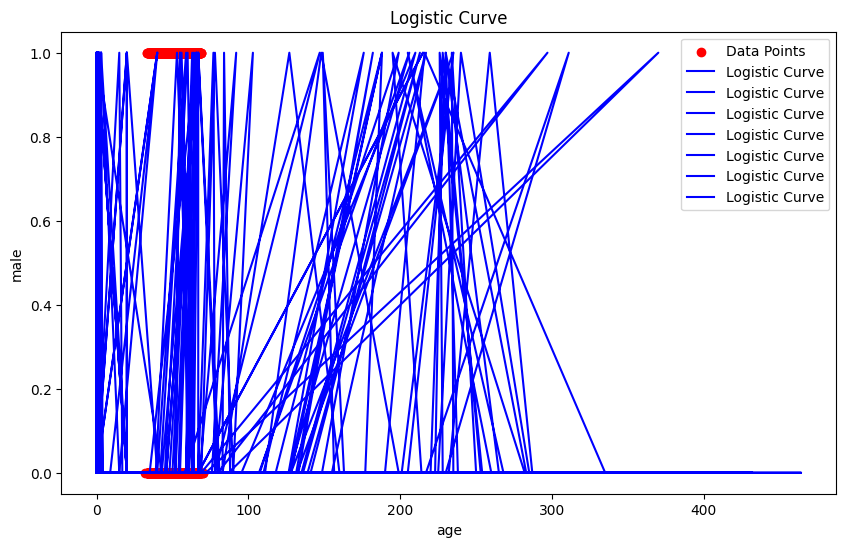

In [44]:
plt.figure(figsize=(10,6))
plt.scatter(df["age"],df["male"],color="red",label="Data Points")
plt.plot(X_test,y_pred,color="blue",label="Logistic Curve")
plt.xlabel("age")
plt.ylabel("male")
plt.title("Logistic Curve")
plt.legend()
plt.show()

In [45]:
y_pred_prob = model.predict_proba(X_test)[:, 1]


In [46]:
results = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted_Prob": y_pred_prob
}).sort_values(by="Predicted_Prob")

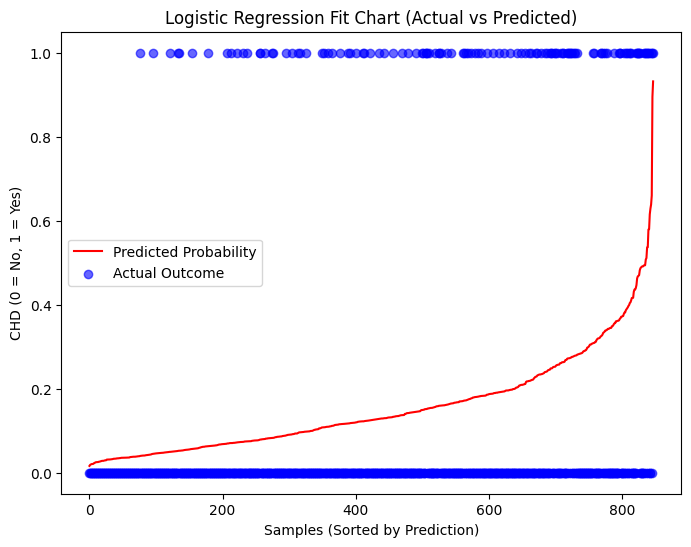

In [47]:
plt.figure(figsize=(8,6))
plt.plot(results["Predicted_Prob"].values, color='red', label="Predicted Probability")
plt.scatter(range(len(results)), results["Actual"].values, color='blue', alpha=0.6, label="Actual Outcome")
plt.title("Logistic Regression Fit Chart (Actual vs Predicted)")
plt.xlabel("Samples (Sorted by Prediction)")
plt.ylabel("CHD (0 = No, 1 = Yes)")
plt.legend()
plt.show()